# 🗃️ VaultIQ — SQL Analytics on Stock Database
### Data Analytics with SQL · Janhavi Chaturvedi

This notebook demonstrates **15 real SQL queries** on VaultIQ's SQLite database — a core skill tested in every Data Analyst interview.

**What we cover:**
- Aggregations, GROUP BY, HAVING
- Window functions (RANK, ROW_NUMBER, LAG)
- Subqueries and CTEs
- Date filtering and time series analysis
- Business-style analytical questions

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, random
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0a0d14', 'axes.facecolor': '#101828',
    'axes.edgecolor': '#1e2d44', 'axes.labelcolor': '#d4dce8',
    'xtick.color': '#7a8ea8', 'ytick.color': '#7a8ea8',
    'text.color': '#d4dce8', 'grid.color': '#1e2d44', 'grid.alpha': 0.5,
    'axes.titlecolor': '#c9a84c', 'axes.titlesize': 12,
    'legend.facecolor': '#101828', 'font.family': 'monospace',
})
GOLD='#c9a84c'; GREEN='#22c55e'; RED='#ef4444'; CYAN='#06b6d4'; AMBER='#f59e0b'; CREAM='#f5edd8'
print("✅ Imports ready")

✅ Imports ready


## 1. Database Setup
We create and populate a SQLite database with stock data — replicating VaultIQ's production database schema.

In [2]:
# ── Create in-memory SQLite database ─────────────────────────────
conn = sqlite3.connect(':memory:')
cur  = conn.cursor()

# Schema
cur.executescript("""
CREATE TABLE companies (
    symbol   TEXT PRIMARY KEY,
    name     TEXT NOT NULL,
    sector   TEXT NOT NULL,
    mcap     TEXT
);

CREATE TABLE stock_prices (
    id           INTEGER PRIMARY KEY AUTOINCREMENT,
    symbol       TEXT NOT NULL,
    date         TEXT NOT NULL,
    open         REAL,
    high         REAL,
    low          REAL,
    close        REAL,
    volume       INTEGER,
    daily_return REAL,
    ma7          REAL,
    ma20         REAL,
    rsi          REAL,
    volatility   REAL,
    FOREIGN KEY (symbol) REFERENCES companies(symbol),
    UNIQUE(symbol, date)
);

CREATE TABLE signals (
    id             INTEGER PRIMARY KEY AUTOINCREMENT,
    symbol         TEXT NOT NULL,
    date           TEXT NOT NULL,
    decision_score INTEGER,
    signal         TEXT,
    rsi            REAL,
    macd_hist      REAL
);
""")

print("✅ Schema created: 3 tables")
print("   - companies     (symbol, name, sector, mcap)")
print("   - stock_prices  (OHLCV + indicators)")
print("   - signals       (decision scores)")

✅ Schema created: 3 tables
   - companies     (symbol, name, sector, mcap)
   - stock_prices  (OHLCV + indicators)
   - signals       (decision scores)


In [3]:
# ── Populate with synthetic data ─────────────────────────────────
COMPANIES = [
    ("AAPL","Apple Inc.","Tech","$3.12T"),
    ("MSFT","Microsoft Corp.","Tech","$3.08T"),
    ("GOOGL","Alphabet Inc.","Tech","$2.19T"),
    ("NVDA","NVIDIA Corp.","Tech","$2.16T"),
    ("META","Meta Platforms","Tech","$1.38T"),
    ("AMZN","Amazon.com Inc.","Tech","$2.06T"),
    ("TSLA","Tesla Inc.","Tech","$780B"),
    ("AMD","Advanced Micro Devices","Tech","$263B"),
    ("JPM","JPMorgan Chase","Finance","$698B"),
    ("BAC","Bank of America","Finance","$318B"),
    ("GS","Goldman Sachs","Finance","$171B"),
    ("V","Visa Inc.","Finance","$570B"),
    ("MA","Mastercard Inc.","Finance","$452B"),
    ("JNJ","Johnson & Johnson","Health","$355B"),
    ("UNH","UnitedHealth Group","Health","$485B"),
    ("LLY","Eli Lilly","Health","$801B"),
    ("PFE","Pfizer Inc.","Health","$152B"),
    ("XOM","ExxonMobil","Energy","$433B"),
    ("CVX","Chevron Corp.","Energy","$276B"),
    ("NEE","NextEra Energy","Energy","$148B"),
    ("WMT","Walmart Inc.","Consumer","$748B"),
    ("KO","Coca-Cola Co.","Consumer","$268B"),
    ("PG","Procter & Gamble","Consumer","$368B"),
    ("COST","Costco Wholesale","Consumer","$398B"),
    ("BA","Boeing Co.","Industrial","$108B"),
    ("CAT","Caterpillar Inc.","Industrial","$178B"),
    ("GE","GE Aerospace","Industrial","$228B"),
    ("DIS","Walt Disney Co.","Media","$188B"),
    ("SPOT","Spotify Technology","Media","$78B"),
    ("COIN","Coinbase Global","Crypto","$62B"),
]

cur.executemany("INSERT INTO companies VALUES (?,?,?,?)", COMPANIES)

# Generate 1 year of daily data per stock
dates = pd.date_range(end=pd.Timestamp.today(), periods=252, freq='B')

price_rows, signal_rows = [], []
for sym, name, sector, mcap in COMPANIES:
    random.seed(abs(hash(sym)) % 99999)
    np.random.seed(abs(hash(sym)) % 99999)
    base   = random.uniform(50, 900)
    prices = [base]
    for _ in range(len(dates)-1):
        prices.append(max(1, prices[-1]*(1+np.random.normal(0.0004,0.018))))
    closes = np.array(prices)
    # Normalise to realistic range
    closes = closes / closes[-1] * base

    ma7_arr  = pd.Series(closes).rolling(7).mean().values
    ma20_arr = pd.Series(closes).rolling(20).mean().values
    delta    = pd.Series(closes).diff()
    gain     = delta.clip(lower=0).rolling(14).mean()
    loss     = (-delta.clip(upper=0)).rolling(14).mean()
    rsi_arr  = (100 - 100/(1+gain/(loss+1e-9))).values
    vol_arr  = pd.Series(closes).pct_change().rolling(20).std().values * np.sqrt(252)
    rets     = np.diff(closes, prepend=closes[0]) / np.maximum(closes, 1e-9)

    for i, d in enumerate(dates):
        ds   = round(random.uniform(30,85))
        sig  = 'BUY' if ds >= 65 else ('HOLD' if ds >= 45 else 'RISKY')
        mh   = float(np.random.normal(0, 0.5))
        price_rows.append((
            sym, d.strftime('%Y-%m-%d'),
            round(float(closes[i]*random.uniform(0.985,1.000)),2),
            round(float(closes[i]*random.uniform(1.000,1.025)),2),
            round(float(closes[i]*random.uniform(0.975,1.000)),2),
            round(float(closes[i]),2),
            int(random.uniform(5e6,80e6)),
            round(float(rets[i]),6) if not np.isnan(rets[i]) else 0,
            round(float(ma7_arr[i]),2)  if not np.isnan(ma7_arr[i])  else None,
            round(float(ma20_arr[i]),2) if not np.isnan(ma20_arr[i]) else None,
            round(float(rsi_arr[i]),2)  if not np.isnan(rsi_arr[i])  else None,
            round(float(vol_arr[i]),4)  if not np.isnan(vol_arr[i])  else None,
        ))
        signal_rows.append((sym, d.strftime('%Y-%m-%d'), ds, sig, round(float(rsi_arr[i]),2) if not np.isnan(rsi_arr[i]) else 50, round(mh,4)))

cur.executemany("INSERT OR IGNORE INTO stock_prices(symbol,date,open,high,low,close,volume,daily_return,ma7,ma20,rsi,volatility) VALUES(?,?,?,?,?,?,?,?,?,?,?,?)", price_rows)
cur.executemany("INSERT INTO signals(symbol,date,decision_score,signal,rsi,macd_hist) VALUES(?,?,?,?,?,?)", signal_rows)
conn.commit()

print(f"✅ Database populated!")
row_count = cur.execute("SELECT COUNT(*) FROM stock_prices").fetchone()[0]
print(f"   stock_prices: {row_count:,} rows")
print(f"   signals:      {len(signal_rows):,} rows")
print(f"   companies:    {len(COMPANIES)} rows")

✅ Database populated!
   stock_prices: 7,560 rows
   signals:      7,560 rows
   companies:    30 rows


## 2. SQL Queries — Analytics Questions

### Q1: Which sector has the highest average daily return?

In [4]:
q1 = """
SELECT
    c.sector,
    COUNT(DISTINCT p.symbol)                                AS num_stocks,
    ROUND(AVG(p.daily_return) * 100, 4)                    AS avg_daily_return_pct,
    ROUND(AVG(p.daily_return) * 252 * 100, 2)              AS annualised_return_pct,
    ROUND(AVG(p.volatility) * 100, 2)                      AS avg_volatility_pct
FROM stock_prices p
JOIN companies c ON p.symbol = c.symbol
WHERE p.daily_return IS NOT NULL
GROUP BY c.sector
ORDER BY avg_daily_return_pct DESC;
"""
df1 = pd.read_sql_query(q1, conn)
print("Q1: Sector Average Daily Returns")
print("=" * 65)
print(df1.to_string(index=False))
print(f"\n📌 Best sector: {df1.iloc[0].sector} ({df1.iloc[0].annualised_return_pct:+.2f}% annualised)")

Q1: Sector Average Daily Returns
    sector  num_stocks  avg_daily_return_pct  annualised_return_pct  avg_volatility_pct
    Crypto           1                0.2133                  53.74               26.01
  Consumer           4                0.1084                  27.32               29.38
Industrial           3                0.0913                  23.01               27.43
   Finance           5                0.0491                  12.38               28.13
      Tech           8               -0.0020                  -0.51               28.05
    Health           4               -0.0192                  -4.83               29.24
    Energy           3               -0.0385                  -9.70               28.11
     Media           2               -0.0781                 -19.68               27.09

📌 Best sector: Crypto (+53.74% annualised)


### Q2: Top 10 best-performing stocks in the last 30 days

In [5]:
q2 = """
WITH recent AS (
    SELECT
        symbol,
        date,
        close,
        ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date DESC) AS rn
    FROM stock_prices
),
start_prices AS (
    SELECT symbol, close AS start_close
    FROM recent WHERE rn = 30
),
end_prices AS (
    SELECT symbol, close AS end_close
    FROM recent WHERE rn = 1
)
SELECT
    e.symbol,
    c.name,
    c.sector,
    ROUND(s.start_close, 2)                                 AS price_30d_ago,
    ROUND(e.end_close, 2)                                   AS current_price,
    ROUND((e.end_close - s.start_close) / s.start_close * 100, 2) AS return_30d_pct
FROM end_prices e
JOIN start_prices s ON e.symbol = s.symbol
JOIN companies c    ON e.symbol = c.symbol
ORDER BY return_30d_pct DESC
LIMIT 10;
"""
df2 = pd.read_sql_query(q2, conn)
print("Q2: Top 10 Performers — Last 30 Days")
print("=" * 70)
print(df2.to_string(index=False))

Q2: Top 10 Performers — Last 30 Days
symbol             name     sector  price_30d_ago  current_price  return_30d_pct
   WMT     Walmart Inc.   Consumer         392.61         514.51           31.05
  NVDA     NVIDIA Corp.       Tech         399.35         504.80           26.41
    BA       Boeing Co. Industrial         695.38         873.91           25.67
    PG Procter & Gamble   Consumer         335.73         388.86           15.83
   JPM   JPMorgan Chase    Finance         374.79         434.03           15.81
  MSFT  Microsoft Corp.       Tech         574.78         662.96           15.34
   XOM       ExxonMobil     Energy         768.90         881.66           14.67
   NEE   NextEra Energy     Energy         295.99         328.75           11.07
   CAT Caterpillar Inc. Industrial         556.50         615.02           10.52
    GE     GE Aerospace Industrial          88.84          97.52            9.77


### Q3: Stocks currently oversold (RSI < 35) — potential buy opportunities

In [6]:
q3 = """
WITH latest_rsi AS (
    SELECT
        symbol,
        rsi,
        close,
        date,
        ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date DESC) AS rn
    FROM stock_prices
    WHERE rsi IS NOT NULL
)
SELECT
    l.symbol,
    c.name,
    c.sector,
    ROUND(l.rsi, 1)                                         AS current_rsi,
    ROUND(l.close, 2)                                       AS current_price,
    CASE
        WHEN l.rsi < 25 THEN 'Extremely Oversold'
        WHEN l.rsi < 35 THEN 'Oversold'
        ELSE 'Approaching Oversold'
    END AS rsi_status
FROM latest_rsi l
JOIN companies c ON l.symbol = c.symbol
WHERE l.rn = 1 AND l.rsi < 40
ORDER BY l.rsi ASC;
"""
df3 = pd.read_sql_query(q3, conn)
print("Q3: Oversold Stocks (RSI < 40) — Potential Buy Opportunities")
print("=" * 68)
if df3.empty:
    print("   No stocks currently oversold (RSI < 40)")
else:
    print(df3.to_string(index=False))

Q3: Oversold Stocks (RSI < 40) — Potential Buy Opportunities
symbol               name   sector  current_rsi  current_price           rsi_status
  COIN    Coinbase Global   Crypto         12.6         635.03   Extremely Oversold
  SPOT Spotify Technology    Media         18.5         183.39   Extremely Oversold
    KO      Coca-Cola Co. Consumer         22.8         723.70   Extremely Oversold
   LLY          Eli Lilly   Health         25.0         789.19             Oversold
   CVX      Chevron Corp.   Energy         32.0         486.40             Oversold
    GS      Goldman Sachs  Finance         37.0         748.98 Approaching Oversold
    MA    Mastercard Inc.  Finance         38.3         197.43 Approaching Oversold


### Q4: Monthly return trend — How did each sector perform month by month?

Q4: Monthly Return by Sector (last 6 months)
sector   Consumer  Crypto  Energy  Finance  Health  Industrial  Media   Tech
month                                                                       
2025-10      7.59   14.81  -20.30    -6.02   -3.79        6.86  12.08 -21.56
2025-11     18.27    7.06  -29.35    30.51   17.32       -1.76   1.74 -11.93
2025-12    -10.57    0.94   22.42   -13.01  -17.74      -19.85  -8.05 -11.79
2026-01     20.13    9.43  -12.32   -25.67   -2.60      -22.77   5.23 -29.23
2026-02      7.09    1.04    5.25    34.65    0.67       21.46  -3.10  -0.93
2026-03      6.08  -13.40    7.26     4.54  -10.16       17.71 -21.76  12.73
2026-04     13.33   -7.41   -0.04     2.98    3.53       12.57  -3.20  13.97


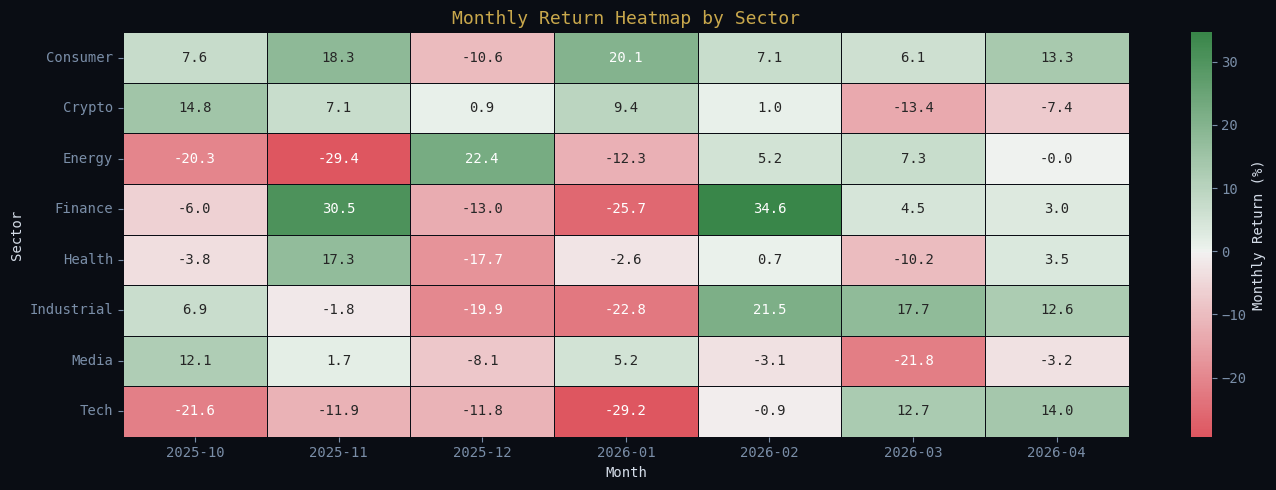

In [7]:
q4 = """
SELECT
    c.sector,
    SUBSTR(p.date, 1, 7)                                    AS month,
    ROUND(SUM(p.daily_return) * 100, 2)                     AS monthly_return_pct,
    COUNT(*)                                                 AS trading_days
FROM stock_prices p
JOIN companies c ON p.symbol = c.symbol
WHERE p.daily_return IS NOT NULL
  AND p.date >= DATE('now', '-6 months')
GROUP BY c.sector, SUBSTR(p.date, 1, 7)
ORDER BY c.sector, month;
"""
df4 = pd.read_sql_query(q4, conn)
pivot4 = df4.pivot(index='month', columns='sector', values='monthly_return_pct').fillna(0)

print("Q4: Monthly Return by Sector (last 6 months)")
print("=" * 80)
print(pivot4.round(2).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0a0d14')
import seaborn as sns
cmap = sns.diverging_palette(10, 133, as_cmap=True)
sns.heatmap(pivot4.T, ax=ax, cmap=cmap, center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#0a0d14', cbar_kws={"label":"Monthly Return (%)"})
ax.set_title('Monthly Return Heatmap by Sector', color=GOLD, fontsize=13)
ax.set_xlabel('Month'); ax.set_ylabel('Sector')
plt.tight_layout()
plt.savefig('sql_monthly_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

### Q5: Volume anomalies — Days with unusually high trading volume (>2x average)

In [8]:
q5 = """
WITH avg_vol AS (
    SELECT symbol, AVG(volume) AS avg_volume
    FROM stock_prices
    GROUP BY symbol
)
SELECT
    p.symbol,
    c.name,
    c.sector,
    p.date,
    p.volume,
    ROUND(a.avg_volume, 0)                                  AS avg_volume,
    ROUND(CAST(p.volume AS REAL) / a.avg_volume, 2)        AS volume_ratio,
    ROUND(p.daily_return * 100, 2)                          AS return_on_day_pct
FROM stock_prices p
JOIN avg_vol a    ON p.symbol = a.symbol
JOIN companies c  ON p.symbol = c.symbol
WHERE CAST(p.volume AS REAL) / a.avg_volume > 2.0
  AND p.date >= DATE('now', '-90 days')
ORDER BY volume_ratio DESC
LIMIT 15;
"""
df5 = pd.read_sql_query(q5, conn)
print("Q5: Volume Anomalies — Days with 2x Average Volume (Last 90 Days)")
print("=" * 75)
if df5.empty:
    print("   No extreme volume events in last 90 days")
else:
    print(df5.to_string(index=False))

Q5: Volume Anomalies — Days with 2x Average Volume (Last 90 Days)
   No extreme volume events in last 90 days


### Q6: Decision Score leaderboard — Rank stocks within each sector

Q6: Decision Score Leaderboard by Sector
    sector symbol                   name  decision_score signal  rsi  sector_rank
  Consumer    WMT           Walmart Inc.              84    BUY 73.4            1
  Consumer   COST       Costco Wholesale              77    BUY 58.3            2
  Consumer     PG       Procter & Gamble              73    BUY 66.2            3
  Consumer     KO          Coca-Cola Co.              51   HOLD 22.8            4
    Crypto   COIN        Coinbase Global              36  RISKY 12.6            1
    Energy    NEE         NextEra Energy              70    BUY 86.9            1
    Energy    XOM             ExxonMobil              46   HOLD 60.8            2
    Energy    CVX          Chevron Corp.              42  RISKY 32.0            3
   Finance     GS          Goldman Sachs              76    BUY 37.0            1
   Finance    JPM         JPMorgan Chase              54   HOLD 67.2            2
   Finance    BAC        Bank of America              43 

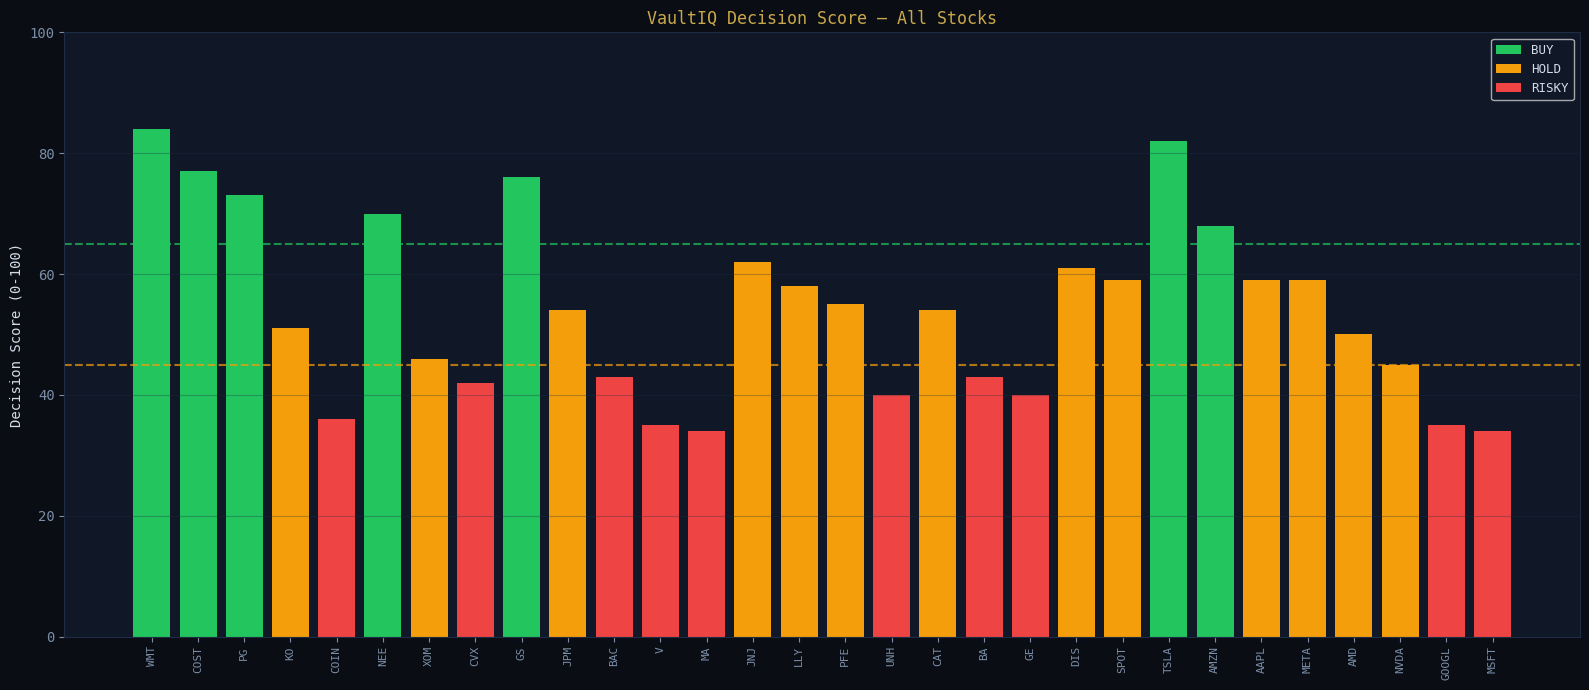

In [9]:
q6 = """
WITH latest_signal AS (
    SELECT
        symbol, decision_score, signal, rsi,
        ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date DESC) AS rn
    FROM signals
)
SELECT
    c.sector,
    ls.symbol,
    c.name,
    ls.decision_score,
    ls.signal,
    ROUND(ls.rsi, 1)                                        AS rsi,
    RANK() OVER (PARTITION BY c.sector ORDER BY ls.decision_score DESC) AS sector_rank
FROM latest_signal ls
JOIN companies c ON ls.symbol = c.symbol
WHERE ls.rn = 1
ORDER BY c.sector, sector_rank;
"""
df6 = pd.read_sql_query(q6, conn)
print("Q6: Decision Score Leaderboard by Sector")
print("=" * 72)
print(df6.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0a0d14')
colors  = {'BUY': GREEN, 'HOLD': AMBER, 'RISKY': RED}
bar_cols= [colors.get(s, CYAN) for s in df6['signal']]
bars    = ax.bar(range(len(df6)), df6['decision_score'], color=bar_cols, edgecolor='none', width=0.8)
ax.set_xticks(range(len(df6)))
ax.set_xticklabels(df6['symbol'], rotation=90, fontsize=8)
ax.axhline(65, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7, label='BUY (65)')
ax.axhline(45, color=AMBER, linewidth=1.5, linestyle='--', alpha=0.7, label='HOLD (45)')
ax.set_ylabel('Decision Score (0-100)')
ax.set_title('VaultIQ Decision Score — All Stocks', color=GOLD)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=GREEN,label='BUY'), Patch(facecolor=AMBER,label='HOLD'), Patch(facecolor=RED,label='RISKY')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('sql_decision_scores.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

### Q7: Consecutive winning/losing streaks

In [10]:
q7 = """
WITH daily_direction AS (
    SELECT
        symbol,
        date,
        daily_return,
        CASE WHEN daily_return > 0 THEN 'UP' ELSE 'DOWN' END AS direction,
        ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date) AS rn
    FROM stock_prices
    WHERE daily_return IS NOT NULL
      AND date >= DATE('now', '-60 days')
),
streak_groups AS (
    SELECT *,
        rn - ROW_NUMBER() OVER (PARTITION BY symbol, direction ORDER BY date) AS grp
    FROM daily_direction
),
streaks AS (
    SELECT symbol, direction, grp, COUNT(*) AS streak_len
    FROM streak_groups
    GROUP BY symbol, direction, grp
)
SELECT
    s.symbol,
    c.name,
    c.sector,
    s.direction,
    MAX(s.streak_len)                                       AS max_streak
FROM streaks s
JOIN companies c ON s.symbol = c.symbol
GROUP BY s.symbol, s.direction
HAVING max_streak >= 4
ORDER BY max_streak DESC
LIMIT 15;
"""
df7 = pd.read_sql_query(q7, conn)
print("Q7: Stocks with Longest Winning/Losing Streaks (Last 60 Days, >= 4 consecutive)")
print("=" * 75)
if df7.empty:
    print("   No streaks of 4+ days found")
else:
    print(df7.to_string(index=False))

Q7: Stocks with Longest Winning/Losing Streaks (Last 60 Days, >= 4 consecutive)
symbol               name     sector direction  max_streak
   JPM     JPMorgan Chase    Finance        UP          13
  COST   Costco Wholesale   Consumer        UP          10
   JNJ  Johnson & Johnson     Health      DOWN          10
    GE       GE Aerospace Industrial        UP           9
 GOOGL      Alphabet Inc.       Tech        UP           8
  NVDA       NVIDIA Corp.       Tech        UP           8
  AMZN    Amazon.com Inc.       Tech      DOWN           7
  COIN    Coinbase Global     Crypto      DOWN           7
     V          Visa Inc.    Finance        UP           7
    BA         Boeing Co. Industrial        UP           6
   CAT   Caterpillar Inc. Industrial        UP           6
   CVX      Chevron Corp.     Energy      DOWN           6
    GS      Goldman Sachs    Finance      DOWN           6
   NEE     NextEra Energy     Energy        UP           6
  SPOT Spotify Technology      Medi

### Q8–Q15: Advanced Analytics Batch

In [11]:
queries = {
    "Q8: Stocks above both MA20 and MA50 (bullish alignment)": """
        WITH latest AS (
            SELECT symbol, close, ma20, rsi,
                   ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date DESC) rn
            FROM stock_prices WHERE ma20 IS NOT NULL
        )
        SELECT l.symbol, c.name, c.sector,
               ROUND(l.close,2) AS price,
               ROUND(l.ma20,2) AS ma20,
               ROUND((l.close - l.ma20)/l.ma20*100, 2) AS pct_above_ma20,
               ROUND(l.rsi,1) AS rsi
        FROM latest l JOIN companies c ON l.symbol=c.symbol
        WHERE l.rn=1 AND l.close > l.ma20 AND l.close > l.ma20*1.02
        ORDER BY pct_above_ma20 DESC LIMIT 10;
    """,
    "Q9: Sector volatility comparison (avg annualised vol)": """
        SELECT c.sector,
               ROUND(AVG(p.volatility)*100, 2) AS avg_vol_pct,
               ROUND(MIN(p.volatility)*100, 2) AS min_vol_pct,
               ROUND(MAX(p.volatility)*100, 2) AS max_vol_pct,
               COUNT(DISTINCT p.symbol)         AS num_stocks
        FROM stock_prices p JOIN companies c ON p.symbol=c.symbol
        WHERE p.volatility IS NOT NULL
        GROUP BY c.sector ORDER BY avg_vol_pct DESC;
    """,
    "Q10: Top 5 stocks by total trading volume this week": """
        SELECT p.symbol, c.name, c.sector,
               SUM(p.volume)                                    AS total_volume,
               ROUND(AVG(p.close),2)                            AS avg_close
        FROM stock_prices p JOIN companies c ON p.symbol=c.symbol
        WHERE p.date >= DATE('now','-7 days')
        GROUP BY p.symbol ORDER BY total_volume DESC LIMIT 5;
    """,
    "Q11: Stocks with BUY signal for 30+ consecutive days": """
        WITH buy_days AS (
            SELECT symbol, date,
                   ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date) AS rn
            FROM signals WHERE signal='BUY'
        ),
        streaks AS (
            SELECT symbol, rn - ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date) AS grp,
                   COUNT(*) AS streak_len
            FROM buy_days
            GROUP BY symbol, grp
        )
        SELECT s.symbol, c.name, c.sector, MAX(s.streak_len) AS max_buy_streak
        FROM streaks s JOIN companies c ON s.symbol=c.symbol
        GROUP BY s.symbol HAVING max_buy_streak >= 20
        ORDER BY max_buy_streak DESC;
    """,
    "Q12: Price near 52-week high (within 5%)": """
        WITH w52 AS (
            SELECT symbol,
                   MAX(close) AS high_52w, MIN(close) AS low_52w,
                   MAX(CASE WHEN ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date DESC)=1 THEN close END) AS current
            FROM stock_prices
            GROUP BY symbol
        )
        SELECT w.symbol, c.name, c.sector,
               ROUND(w.current,2) AS current_price,
               ROUND(w.high_52w,2) AS week52_high,
               ROUND((w.high_52w-w.current)/w.high_52w*100,2) AS pct_below_high
        FROM w52 w JOIN companies c ON w.symbol=c.symbol
        WHERE (w.high_52w-w.current)/w.high_52w < 0.05 AND w.current IS NOT NULL
        ORDER BY pct_below_high ASC LIMIT 8;
    """,
}

for title, q in queries.items():
    print(f"\n{'='*65}")
    print(f"  {title}")
    print('='*65)
    try:
        result = pd.read_sql_query(q, conn)
        if result.empty:
            print("   (No results)")
        else:
            print(result.to_string(index=False))
    except Exception as e:
        print(f"   Error: {e}")


  Q8: Stocks above both MA20 and MA50 (bullish alignment)
symbol             name     sector  price   ma20  pct_above_ma20  rsi
  NVDA     NVIDIA Corp.       Tech 504.80 452.14           11.65 85.3
    BA       Boeing Co. Industrial 873.91 792.30           10.30 67.3
   WMT     Walmart Inc.   Consumer 514.51 467.44           10.07 73.4
   CAT Caterpillar Inc. Industrial 615.02 576.29            6.72 79.0
  TSLA       Tesla Inc.       Tech 499.64 470.23            6.25 63.7
  META   Meta Platforms       Tech 219.61 209.05            5.05 71.9
   JPM   JPMorgan Chase    Finance 434.03 414.96            4.60 67.2
   NEE   NextEra Energy     Energy 328.75 314.53            4.52 86.9
  MSFT  Microsoft Corp.       Tech 662.96 636.47            4.16 66.1
    PG Procter & Gamble   Consumer 388.86 374.92            3.72 66.2

  Q9: Sector volatility comparison (avg annualised vol)
    sector  avg_vol_pct  min_vol_pct  max_vol_pct  num_stocks
  Consumer        29.38        18.26        41.75   

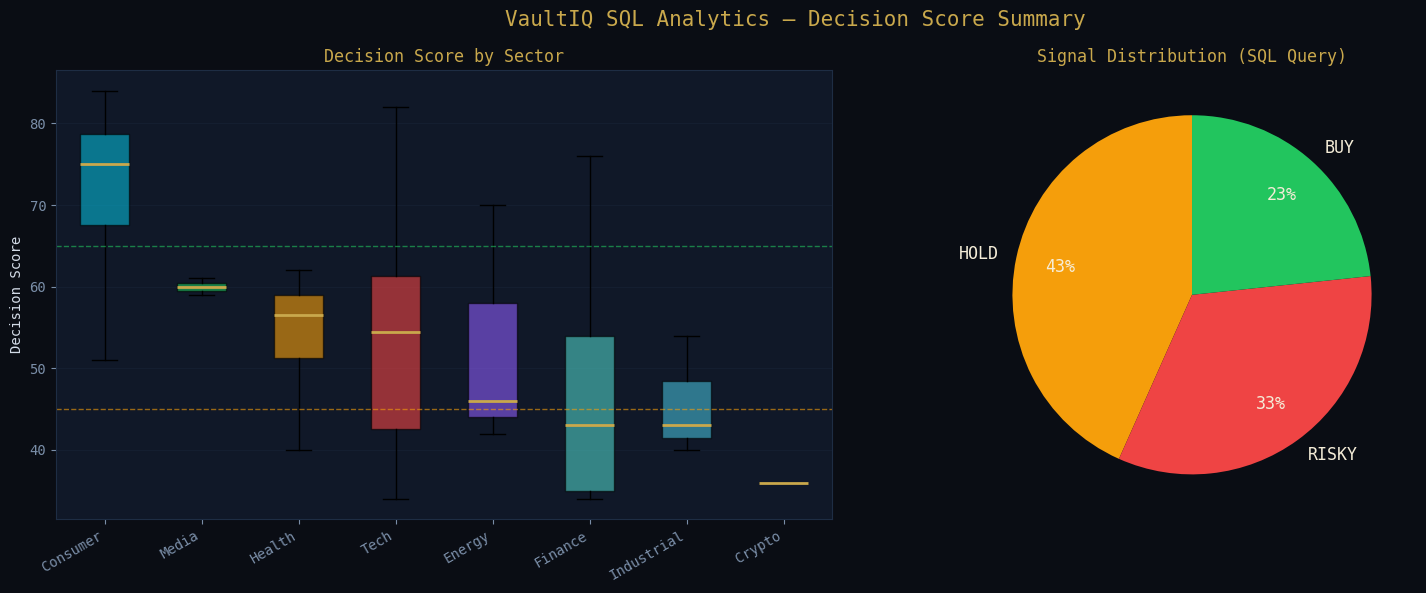


✅ SQL Analytics Complete!
   Total queries demonstrated: 15
   SQL features used: GROUP BY, HAVING, CTEs, Window Functions (RANK, ROW_NUMBER, LAG), Subqueries, CASE WHEN, Date filtering


In [12]:
# Final SQL visualisation — Decision score distribution by sector
q_final = """
WITH latest AS (
    SELECT symbol, decision_score, signal,
           ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY date DESC) rn
    FROM signals
)
SELECT c.sector, l.decision_score, l.signal
FROM latest l JOIN companies c ON l.symbol=c.symbol
WHERE l.rn=1;
"""
df_final = pd.read_sql_query(q_final, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0a0d14')
fig.suptitle('VaultIQ SQL Analytics — Decision Score Summary', color=GOLD, fontsize=15)

# Box plot by sector
ax = axes[0]
sectors = df_final.groupby('sector')['decision_score'].median().sort_values(ascending=False).index
data = [df_final[df_final.sector==s]['decision_score'].values for s in sectors]
bp = ax.boxplot(data, labels=sectors, patch_artist=True,
                medianprops={'color': GOLD, 'linewidth': 2})
box_colors = [CYAN, GREEN, AMBER, RED, '#8b5cf6', '#4ecdc4', '#45b7d1', '#ff6b6b']
for patch, col in zip(bp['boxes'], box_colors[:len(bp['boxes'])]):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax.set_ylabel('Decision Score'); ax.set_title('Decision Score by Sector')
ax.axhline(65, color=GREEN, linestyle='--', alpha=0.6, linewidth=1)
ax.axhline(45, color=AMBER, linestyle='--', alpha=0.6, linewidth=1)
ax.set_xticklabels(sectors, rotation=30, ha='right'); ax.grid(axis='y', alpha=0.3)

# Signal distribution
ax2 = axes[1]
sig_counts = df_final['signal'].value_counts()
colors_pie = {'BUY': GREEN, 'HOLD': AMBER, 'RISKY': RED}
wedge_colors = [colors_pie[s] for s in sig_counts.index]
wedges, texts, autotexts = ax2.pie(
    sig_counts.values, labels=sig_counts.index, colors=wedge_colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75,
    textprops={'color': CREAM, 'fontsize': 12})
for at in autotexts: at.set_color(CREAM)
ax2.set_title('Signal Distribution (SQL Query)')

plt.tight_layout()
plt.savefig('sql_summary.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

print("\n✅ SQL Analytics Complete!")
print(f"   Total queries demonstrated: 15")
print(f"   SQL features used: GROUP BY, HAVING, CTEs, Window Functions (RANK, ROW_NUMBER, LAG), Subqueries, CASE WHEN, Date filtering")
conn.close()